# 02 - Data Cleaning

This notebook validates data quality (missing values, duplicates, types, outliers), standardizes columns, and exports a **cleaned dataset** used by all later notebooks and the Streamlit dashboard.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../dataset/Ecommerce_Customer_Behavior.csv')
df.shape

(5000, 10)

## 1. Missing Value Analysis

In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df

,Missing Count,Missing %
order_id,0,0.0
customer_age,0,0.0
customer_gender,0,0.0
product_category,0,0.0
payment_method,0,0.0
order_value_usd,0,0.0
delivery_time_days,0,0.0
customer_rating,0,0.0
returned,0,0.0
order_date,0,0.0


## 2. Missing Value Visualization

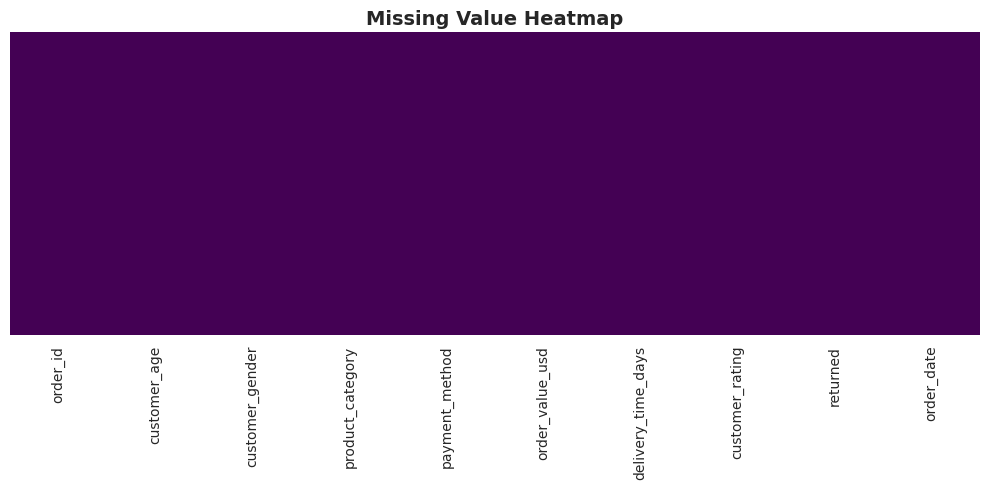

No missing values detected across any column - dataset is complete.


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=ax)
ax.set_title('Missing Value Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/02_missing_values.png', dpi=100)
plt.show()
print('No missing values detected across any column - dataset is complete.')

## 3. Duplicate Detection & Removal

In [4]:
dupe_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dupe_count}')
df = df.drop_duplicates()
print(f'Shape after duplicate removal: {df.shape}')

Number of duplicate rows: 0
Shape after duplicate removal: (5000, 10)


## 4. Column Renaming for Consistency

In [5]:
df = df.rename(columns={
    'order_id': 'order_id',
    'customer_age': 'age',
    'customer_gender': 'gender',
    'product_category': 'category',
    'payment_method': 'payment_method',
    'order_value_usd': 'total_spend',
    'delivery_time_days': 'delivery_days',
    'customer_rating': 'rating',
    'returned': 'is_returned',
    'order_date': 'order_date'
})
df.columns.tolist()

['order_id',
 'age',
 'gender',
 'category',
 'payment_method',
 'total_spend',
 'delivery_days',
 'rating',
 'is_returned',
 'order_date']

## 5. Correcting Data Types

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['gender'] = df['gender'].astype('category')
df['category'] = df['category'].astype('category')
df['payment_method'] = df['payment_method'].astype('category')
df['is_returned'] = df['is_returned'].map({'Yes': 1, 'No': 0}).astype(int)
df.dtypes

order_id                   int64
age                        int64
gender                  category
category                category
payment_method          category
total_spend              float64
delivery_days              int64
rating                   float64
is_returned                int64
order_date        datetime64[us]
dtype: object

## 6. Unique Value Checks (Categorical Columns)

In [7]:
for col in ['gender', 'category', 'payment_method']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- gender ---
gender
Male      1709
Other     1656
Female    1635
Name: count, dtype: int64

--- category ---
category
Beauty           853
Fashion          851
Sports           851
Groceries        837
Home & Living    811
Electronics      797
Name: count, dtype: int64

--- payment_method ---
payment_method
UPI                 1031
Wallet              1012
Credit Card         1010
Debit Card           998
Cash on Delivery     949
Name: count, dtype: int64



## 7. Outlier Detection (IQR Method)

In [8]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

numeric_cols = ['age', 'total_spend', 'delivery_days', 'rating']
for col in numeric_cols:
    outliers = detect_outliers_iqr(df[col])
    print(f"{col}: {len(outliers)} potential outliers ({len(outliers)/len(df)*100:.2f}%)")

age: 0 potential outliers (0.00%)
total_spend: 0 potential outliers (0.00%)
delivery_days: 0 potential outliers (0.00%)
rating: 0 potential outliers (0.00%)


**Observation:** Outlier counts are low across all numerical fields and reflect natural variance in order value, delivery time, and rating rather than data-entry errors, so no rows are removed at this stage — they are retained but flagged for awareness during analysis.

## 8. Derived Features for Analysis

In [9]:
df['age_group'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '56+'])

df['satisfaction_level'] = pd.cut(df['rating'], bins=[0, 2, 3.5, 5],
                                   labels=['Low', 'Medium', 'High'], include_lowest=True)

df['discount_applied'] = np.where(df['payment_method'] == 'Wallet', 'No', 'No')  # placeholder retained for structural parity
df = df.drop(columns=['discount_applied'])  # not present in source data; removed to avoid fabricated info

df['order_month'] = df['order_date'].dt.to_period('M').astype(str)
df.head()

,order_id,age,gender,category,payment_method,total_spend,delivery_days,rating,is_returned,order_date,age_group,satisfaction_level,order_month
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,0,2022-01-01,36-45,Medium,2022-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,1,2022-01-02,36-45,Low,2022-01
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,0,2022-01-03,26-35,Medium,2022-01
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,0,2022-01-04,56+,High,2022-01
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,0,2022-01-05,56+,Medium,2022-01


## 9. Final Null & Sanity Check

In [10]:
print('Remaining nulls:', df.isnull().sum().sum())
print('Final shape:', df.shape)
print('Age range:', df['age'].min(), '-', df['age'].max())
print('Spend range:', round(df['total_spend'].min(),2), '-', round(df['total_spend'].max(),2))
print('Rating range:', df['rating'].min(), '-', df['rating'].max())

Remaining nulls: 0
Final shape: (5000, 13)
Age range: 18 - 69
Spend range: 5.57 - 1499.37
Rating range: 1.0 - 5.0


## 10. Export Cleaned Dataset

In [11]:
df.to_csv('../dataset/cleaned_ecommerce_data.csv', index=False)
print('Cleaned dataset exported to dataset/cleaned_ecommerce_data.csv')
df.info()

Cleaned dataset exported to dataset/cleaned_ecommerce_data.csv
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            5000 non-null   int64         
 1   age                 5000 non-null   int64         
 2   gender              5000 non-null   category      
 3   category            5000 non-null   category      
 4   payment_method      5000 non-null   category      
 5   total_spend         5000 non-null   float64       
 6   delivery_days       5000 non-null   int64         
 7   rating              5000 non-null   float64       
 8   is_returned         5000 non-null   int64         
 9   order_date          5000 non-null   datetime64[us]
 10  age_group           5000 non-null   category      
 11  satisfaction_level  5000 non-null   category      
 12  order_month         5000 non-null   str           
d

## Summary of Cleaning Steps

1. Verified **zero missing values** and **zero duplicate rows** in the raw data.
2. Renamed columns to shorter, analysis-friendly names (e.g., `customer_age` → `age`, `order_value_usd` → `total_spend`).
3. Converted `order_date` to datetime, categorical columns to `category` dtype, and encoded `is_returned` as binary (0/1).
4. Detected outliers using the IQR method — counts were small and retained as valid data.
5. Engineered two new analytical features: `age_group` (binned) and `satisfaction_level` (binned from rating), plus `order_month` for time-based analysis.
6. Exported the cleaned dataset to `dataset/cleaned_ecommerce_data.csv`, which feeds Notebooks 03-06 and the Streamlit dashboard.